In [6]:
import matplotlib.pyplot as plt
import pylab
import os
import numpy as np

In [14]:
prename = r"/home/kelsey/simulations/terra/CU Energy Resolution/1-22-2026 X-rays on Sh0136/Rise Time Varying"
PT = 10
Strip = "G"
txtname = r"Sh0136 Strip " + Strip + " 250 V 5x RT " + str(PT) + " ADCCH-Count"
file_path = os.path.join(prename)
name = os.path.join(prename,txtname+".txt")
filename = os.path.join(prename,txtname+".png")
print(name)

if os.path.exists(file_path):
    print(f"Path exists: {file_path}")
    pltfile = open(name, "r")
    nlines = len(open(name).readlines(  ))
    print(nlines)

    tarray = [0]*3
    ADC = [0]*nlines
    Nhits = [0]*nlines

    for i, x in enumerate(pltfile):
        tarray = x.strip().split(' ')
        ADC[i] = int(tarray[0])
        Nhits[i] = int(tarray[1])
        #print(tarray[0]

/home/kelsey/simulations/terra/CU Energy Resolution/1-22-2026 X-rays on Sh0136/Rise Time Varying/Sh0136 Strip G 250 V 5x RT 10 ADCCH-Count.txt
Path exists: /home/kelsey/simulations/terra/CU Energy Resolution/1-22-2026 X-rays on Sh0136/Rise Time Varying
16384


22 keV: 5081
88 keV: 896
1000.0000000000003


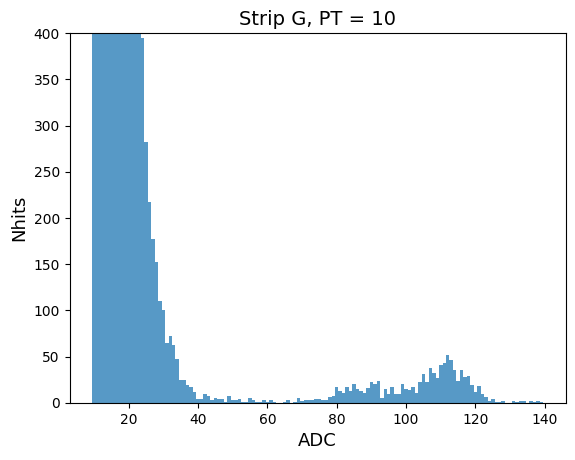

In [15]:
min = 10
max = 140
ymin = 0
ymax = 400
Normkev = 1000 #We'll scale so that there are ~2000 events in the 60 - 140 range. 
lowtot = sum(Nhits[20:40])
tot = sum(Nhits[60:140])
print("22 keV: " + str(lowtot))
print("88 keV: " + str(tot))
y_scale = Normkev/tot
#y_scale = 1 #No scaling

title = "Strip " + Strip + ", PT = " + str(PT)
plt.title(title,fontsize=14)
plt.xlabel("ADC",fontsize=13)
plt.ylabel("Nhits",fontsize=13)
plt.ylim(ymin,ymax)

Nhits = np.array(Nhits) * y_scale

plt.bar(ADC[min:max], Nhits[min:max], 1, alpha=0.75)
tot = sum(Nhits[60:140])
print(tot)
savename = os.path.join("/home/kelsey/GitScripts/ActiveScripts/Python",title+".png")
plt.savefig(savename) #Save the file